# 16 · Structured block pruning

**Goal:** remove each repeated 5×5, 128-channel depthwise-separable block independently, recover the best candidate with EMA-range QAT, export full INT8, and hand the exact FlatBuffer to the ESP32 profiler. No layer is masked: the selected block is absent from the deployed graph.

## Evidence flow

`EMA-QAT recovered float weights → remove block7/block8/block9 → short equal-budget screen → select by validation PR-AUC → full float fine-tuning → EMA-QAT recovery → locked test → full-INT8 export → physical ESP32 profile`

The three blocks have identical input/output shapes, so this experiment isolates *where* one late block can be removed without simultaneously changing widths.

In [1]:
import hashlib, json, subprocess, time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display

from vww_esp32.config import load_config, seed_everything
from vww_esp32.evaluation import classification_metrics, collect_predictions, expected_calibration_error, select_threshold
from vww_esp32.exporting import convert_full_integer, inspect_tflite, run_tflite
from vww_esp32.modeling import build_tiny_mobilenet_v1, compile_model
from vww_esp32.preprocessing import make_dataset, representative_dataset, split_manifest
from vww_esp32.profiling import profile_model
from vww_esp32.pruning import block_pruning_specs, transfer_structured_weights
from vww_esp32.qat import build_qat_mobilenet_v1, copy_compatible_weights, copy_qat_weights_to_float

config, ROOT = load_config('configs/pruning.yaml')
seed = int(config['project']['seed']); seed_everything(seed)
IMAGE_SIZE = tuple(config['preprocessing']['image_size'])
BATCH_SIZE = int(config['preprocessing']['batch_size'])
OUT = ROOT / 'artifacts/pruning/block'
for child in ('models', 'reports', 'figures', 'logs'): (OUT / child).mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
print(f'TensorFlow {tf.__version__} · root={ROOT}')

TensorFlow 2.20.0 · root=/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32


## 1 · Freeze data and reference evidence

All candidates use the existing train/validation/test manifests. Selection uses validation PR-AUC only; the held-out test set is opened once for the recovered winner.

In [2]:
manifest = pd.read_csv(ROOT / 'data/processed/manifest.csv')
splits = split_manifest(manifest)
assert {key: len(value) for key, value in splits.items()} == {'train': 12000, 'val': 2000, 'test': 2000}
assert sum((~frame.image_path.map(lambda value: Path(value).exists())).sum() for frame in splits.values()) == 0
train_ds = make_dataset(splits['train'], IMAGE_SIZE, BATCH_SIZE, training=True, seed=seed)
val_ds = make_dataset(splits['val'], IMAGE_SIZE, BATCH_SIZE, training=False)
test_ds = make_dataset(splits['test'], IMAGE_SIZE, BATCH_SIZE, training=False)
parent = tf.keras.models.load_model(ROOT / config['reference']['float_model'])
parent_metrics = json.loads((ROOT / config['reference']['int8_metrics']).read_text())
_, _, parent_profile = profile_model(parent, training_batch_size=BATCH_SIZE)
parent_record = {'role': 'pruning_parent', 'source': config['reference']['float_model'], 'int8_source': config['reference']['int8_model'], 'accuracy': parent_metrics['accuracy'], 'recall': parent_metrics['recall'], 'f1': parent_metrics['f1'], 'pr_auc': parent_metrics['pr_auc']}
(OUT / 'reports/parent_record.json').write_text(json.dumps(parent_record, indent=2) + '\n')
display(pd.DataFrame([{'split': key, 'images': len(value), 'person_rate': value.label.mean()} for key, value in splits.items()]))

,split,images,person_rate
0,train,12000,0.5000
1,val,2000,0.4945
2,test,2000,0.4905


## 2 · Physically rebuild three block ablations

Surviving layers keep their EMA-QAT recovered float tensors. Each target is audited to prove that six Keras layers (depthwise, BatchNorm, ReLU6, pointwise, BatchNorm, ReLU6) disappeared and that parameters/MACs decreased.

,candidate,removed,parameters,macs,mac_reduction_pct,peak_live_int8,layers
0,remove_block7,block7,93233,3555136,10.97774,51200,64
1,remove_block8,block8,93233,3555136,10.97774,51200,64
2,remove_block9,block9,93233,3555136,10.97774,51200,64


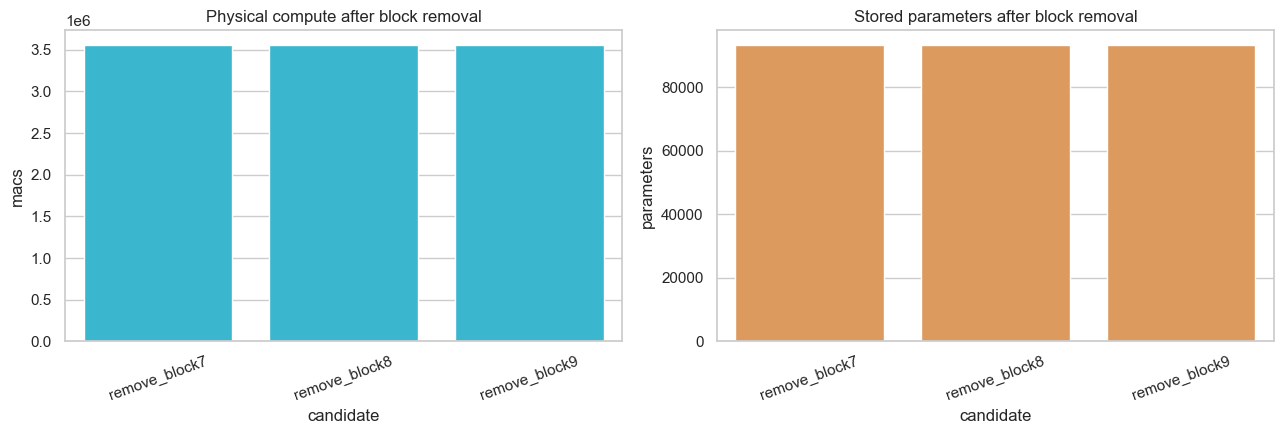

In [3]:
specs = {spec.name: spec for spec in block_pruning_specs()}
candidates, structural_rows = {}, []
for name, spec in specs.items():
    model = build_tiny_mobilenet_v1(input_shape=(*IMAGE_SIZE, 3), dropout=config['model']['dropout'], l2=config['model']['l2'], channel_schedule=spec.channel_schedule, removed_blocks=spec.removed_blocks)
    transfer = transfer_structured_weights(parent, model, spec.channel_schedule, spec.removed_blocks, method=spec.ranking)
    layers, liveness, profile = profile_model(model, training_batch_size=BATCH_SIZE)
    assert profile['estimated_macs_batch1'] < parent_profile['estimated_macs_batch1']
    candidates[name] = model
    structural_rows.append({'candidate': name, 'removed': spec.removed_blocks[0], 'parameters': profile['parameters'], 'macs': profile['estimated_macs_batch1'], 'mac_reduction_pct': 100 * (1 - profile['estimated_macs_batch1'] / parent_profile['estimated_macs_batch1']), 'peak_live_int8': profile['peak_live_activation_int8_bytes_batch1_hypothetical'], 'layers': profile['layers']})
    (OUT / 'reports' / f'{name}_transfer.json').write_text(json.dumps(transfer, indent=2) + '\n')
structure = pd.DataFrame(structural_rows)
structure.to_csv(OUT / 'reports/structural_screen.csv', index=False)
display(structure)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=structure, x='candidate', y='macs', ax=axes[0], color='#21C7E8'); axes[0].tick_params(axis='x', rotation=20); axes[0].set_title('Physical compute after block removal')
sns.barplot(data=structure, x='candidate', y='parameters', ax=axes[1], color='#F2994A'); axes[1].tick_params(axis='x', rotation=20); axes[1].set_title('Stored parameters after block removal')
fig.tight_layout(); fig.savefig(OUT / 'figures/block_structure.png', dpi=170, bbox_inches='tight'); plt.show()

## 3 · Equal-budget float screening

Every ablation receives exactly the same short recovery budget. Validation PR-AUC is the primary selector, with recall and F1 reported as safety signals. This screen avoids spending full QAT time on all three blocks.

In [4]:
screen_rows = []
for name, model in candidates.items():
    compile_model(model, learning_rate=float(config['training']['learning_rate']), label_smoothing=float(config['training']['label_smoothing']))
    started = time.monotonic()
    history = model.fit(train_ds, validation_data=val_ds, epochs=int(config['training']['screening_epochs']), verbose=1)
    y_val, p_val = collect_predictions(model, val_ds)
    choice = select_threshold(y_val, p_val, objective=config['evaluation']['threshold_objective'], minimum_recall=float(config['evaluation']['minimum_recall']))
    metrics = classification_metrics(y_val, p_val, choice['threshold'])
    metrics.update({'candidate': name, 'seconds': time.monotonic() - started, 'best_epoch_pr_auc': max(history.history['val_pr_auc'])})
    screen_rows.append(metrics)
    model.save(OUT / 'models' / f'{name}_screened.keras')
screen = pd.DataFrame(screen_rows).sort_values(['pr_auc', 'f1'], ascending=False)
screen.to_csv(OUT / 'reports/validation_screen.csv', index=False)
winner_name = screen.iloc[0].candidate; winner_spec = specs[winner_name]; winner_float = candidates[winner_name]
display(screen[['candidate', 'threshold', 'accuracy', 'precision', 'recall', 'specificity', 'f1', 'pr_auc', 'seconds']])
print('Selected by validation PR-AUC:', winner_name)

Epoch 1/3


  1/188 ━━━━━━━━━━━━━━━━━━━━ 18:38 6s/step - accuracy: 0.5781 - loss: 0.8069 - pr_auc: 0.5524 - precision: 0.6579 - recall: 0.6410 - roc_auc: 0.4846

  2/188 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.5430 - loss: 0.8105 - pr_auc: 0.5198 - precision: 0.5966 - recall: 0.5999 - roc_auc: 0.4832

  3/188 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.5373 - loss: 0.7978 - pr_auc: 0.5135 - precision: 0.5710 - recall: 0.5824 - roc_auc: 0.4978

  4/188 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.5358 - loss: 0.7910 - pr_auc: 0.5128 - precision: 0.5605 - recall: 0.5794 - roc_auc: 0.5055

...

30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step


,candidate,threshold,accuracy,precision,recall,specificity,f1,pr_auc,seconds
2,remove_block9,0.30,0.6510,0.599863,0.883721,0.423343,0.714636,0.768154,110.218907
1,remove_block8,0.32,0.6655,0.618168,0.846309,0.488625,0.714469,0.759351,62.192171
0,remove_block7,0.38,0.6630,0.620875,0.817998,0.511375,0.705934,0.733091,54.839946


Selected by validation PR-AUC: remove_block9


## 4 · Full float fine-tuning of the selected topology

Candidate screening chooses the structure; it is not the final recovery. The winner now receives a lower-learning-rate float fine-tune with early stopping. Recording pre- and post-fine-tune validation metrics separates pruning damage, float recovery, and later QAT effects.

In [5]:
pre_finetune_metrics = screen.set_index('candidate').loc[winner_name].to_dict()
fine_tuned_float = winner_float
compile_model(fine_tuned_float, learning_rate=float(config['training']['full_finetune_learning_rate']), label_smoothing=float(config['training']['label_smoothing']))
float_callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max', patience=int(config['training']['early_stopping_patience']), restore_best_weights=True), tf.keras.callbacks.ReduceLROnPlateau(monitor='val_pr_auc', mode='max', factor=0.3, patience=int(config['training']['reduce_lr_patience']), min_lr=1e-7)]
float_started = time.monotonic()
float_history = fine_tuned_float.fit(train_ds, validation_data=val_ds, epochs=int(config['training']['full_finetune_epochs']), callbacks=float_callbacks, verbose=1)
float_training_seconds = time.monotonic() - float_started
y_val_float, p_val_float = collect_predictions(fine_tuned_float, val_ds)
float_threshold = select_threshold(y_val_float, p_val_float, objective=config['evaluation']['threshold_objective'], minimum_recall=float(config['evaluation']['minimum_recall']))['threshold']
post_finetune_metrics = classification_metrics(y_val_float, p_val_float, float_threshold)
fine_tuned_float.save(OUT / 'models/block_pruned_finetuned_float.keras')
pd.DataFrame(float_history.history).to_csv(OUT / 'logs/full_float_history.csv', index=False)
display(pd.DataFrame([pre_finetune_metrics, post_finetune_metrics], index=['after screen', 'after full float'])[['accuracy', 'precision', 'recall', 'specificity', 'f1', 'pr_auc']])

Epoch 1/8


  1/188 ━━━━━━━━━━━━━━━━━━━━ 20:42 7s/step - accuracy: 0.7188 - loss: 0.5837 - pr_auc: 0.6608 - precision: 0.6452 - recall: 0.7407 - roc_auc: 0.7923

  2/188 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - accuracy: 0.7266 - loss: 0.5873 - pr_auc: 0.6607 - precision: 0.6559 - recall: 0.7522 - roc_auc: 0.7821

  3/188 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - accuracy: 0.7326 - loss: 0.5764 - pr_auc: 0.6892 - precision: 0.6800 - recall: 0.7469 - roc_auc: 0.7908

  4/188 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.7233 - loss: 0.5827 - pr_auc: 0.6981 - precision: 0.6865 - recall: 0.7255 - roc_auc: 0.7833

...

29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step


,accuracy,precision,recall,specificity,f1,pr_auc
after screen,0.6510,0.599863,0.883721,0.423343,0.714636,0.768154
after full float,0.6635,0.613181,0.865521,0.465875,0.717820,0.774536


## 5 · EMA-range QAT recovery for the winner

The selected QAT recipe is applied only after structural selection. BatchNorm is frozen, activation observers warm on training batches, and the training-only quantizers are stripped before export.

In [6]:
qat_model = build_qat_mobilenet_v1(input_shape=(*IMAGE_SIZE, 3), dropout=config['model']['dropout'], l2=config['model']['l2'], range_mode=config['qat']['range_mode'], ema_decay=float(config['qat']['ema_decay']), channel_schedule=winner_spec.channel_schedule, removed_blocks=winner_spec.removed_blocks)
transfer = copy_compatible_weights(fine_tuned_float, qat_model)
for layer in qat_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization): layer.trainable = False
for images, _ in train_ds.take(64): _ = qat_model(images, training=True)
compile_model(qat_model, learning_rate=float(config['training']['qat_learning_rate']), label_smoothing=0.0)
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max', patience=int(config['training']['early_stopping_patience']), restore_best_weights=True), tf.keras.callbacks.ReduceLROnPlateau(monitor='val_pr_auc', mode='max', factor=0.3, patience=int(config['training']['reduce_lr_patience']), min_lr=1e-7)]
qat_started = time.monotonic()
history = qat_model.fit(train_ds, validation_data=val_ds, epochs=int(config['training']['qat_recovery_epochs']), callbacks=callbacks, verbose=1)
qat_training_seconds = time.monotonic() - qat_started
deployment_model = build_tiny_mobilenet_v1(input_shape=(*IMAGE_SIZE, 3), dropout=config['model']['dropout'], l2=config['model']['l2'], channel_schedule=winner_spec.channel_schedule, removed_blocks=winner_spec.removed_blocks)
strip = copy_qat_weights_to_float(qat_model, deployment_model)
assert not strip['skipped_layers'], strip
deployment_model.save(OUT / 'models/block_pruned_qat_float.keras')
pd.DataFrame(history.history).to_csv(OUT / 'logs/qat_history.csv', index=False)

Epoch 1/10


  1/188 ━━━━━━━━━━━━━━━━━━━━ 24:05 8s/step - accuracy: 0.7812 - loss: 0.5152 - pr_auc: 0.8463 - precision: 0.7941 - recall: 0.7941 - roc_auc: 0.8201

  2/188 ━━━━━━━━━━━━━━━━━━━━ 58s 315ms/step - accuracy: 0.7539 - loss: 0.5401 - pr_auc: 0.8283 - precision: 0.7758 - recall: 0.7594 - roc_auc: 0.8014

  3/188 ━━━━━━━━━━━━━━━━━━━━ 40s 221ms/step - accuracy: 0.7439 - loss: 0.5463 - pr_auc: 0.8181 - precision: 0.7610 - recall: 0.7424 - roc_auc: 0.7974

  4/188 ━━━━━━━━━━━━━━━━━━━━ 33s 181ms/step - accuracy: 0.7337 - loss: 0.5550 - pr_auc: 0.8068 - precision: 0.7469 - recall: 0.7274 - roc_auc: 0.7889

...

184/188 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7339 - loss: 0.5375 - pr_auc: 0.8150 - precision: 0.7517 - recall: 0.7053 - roc_auc: 0.8115

185/188 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7339 - loss: 0.5375 - pr_auc: 0.8150 - precision: 0.7516 - recall: 0.7053 - roc_auc: 0.8115

186/188 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7339 - loss: 0.5375 - pr_auc: 0.8150 - precision: 0.7516 - recall: 0.7053 - roc_auc: 0.8115

187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7339 - loss: 0.5375 - pr_auc: 0.8150 - precision: 0.7516 - recall: 0.7054 - roc_auc: 0.8115

188/188 ━━━━━━━━━━━━━━━━━━━━ 26s 137ms/step - accuracy: 0.7335 - loss: 0.5383 - pr_auc: 0.8129 - precision: 0.7444 - recall: 0.7112 - roc_auc: 0.8102 - val_accuracy: 0.7045 - val_loss: 0.5768 - val_pr_auc: 0.7763 - val_precision: 0.7131 - val_recall: 0.6734 - val_roc_auc: 0.7741 - learning_rate: 9.0000e-07


## 6 · Locked evaluation, full-INT8 export, and resource gates

The decision threshold is selected on validation data and locked. Test data is used only for the final float/INT8 report. Structural and quality gates are recorded separately so an accurate but non-smaller graph cannot pass as pruning.

In [7]:
y_val, p_val = collect_predictions(deployment_model, val_ds)
threshold = select_threshold(y_val, p_val, objective=config['evaluation']['threshold_objective'], minimum_recall=float(config['evaluation']['minimum_recall']))['threshold']
y_test, p_float = collect_predictions(deployment_model, test_ds)
float_metrics = classification_metrics(y_test, p_float, threshold)
model_path = OUT / 'models/vww_block_pruned_qat_int8.tflite'
representative = representative_dataset(splits['train'], IMAGE_SIZE, int(config['export']['representative_samples']), seed)
convert_full_integer(deployment_model, representative, model_path)
contract = inspect_tflite(model_path)
test_images = np.concatenate([np.asarray(images) for images, _ in test_ds])
p_int8 = run_tflite(model_path, test_images)
int8_metrics = classification_metrics(y_test, p_int8, threshold)
int8_metrics['expected_calibration_error_10_bins'] = expected_calibration_error(y_test, p_int8)
int8_metrics['probability_mae_vs_float'] = float(np.mean(np.abs(p_int8 - p_float)))
layers, liveness, model_profile = profile_model(deployment_model, training_batch_size=BATCH_SIZE)
gates = {'full_int8': contract['input']['dtype'] == contract['output']['dtype'] == 'int8', 'physically_fewer_macs': model_profile['estimated_macs_batch1'] < parent_profile['estimated_macs_batch1'], 'recall': int8_metrics['recall'] >= config['deployment_gate']['minimum_test_recall'], 'f1': int8_metrics['f1'] >= config['deployment_gate']['minimum_test_f1'], 'parent_f1_retained': int8_metrics['f1'] >= parent_metrics['f1'] - config['deployment_gate']['maximum_f1_drop_from_parent'], 'model_bytes': model_path.stat().st_size <= config['deployment_gate']['max_model_bytes']}
summary = {'experiment': 'structured_block_pruning', 'parent': parent_record, 'selected_candidate': winner_name, 'spec': winner_spec.as_dict(), 'screen_validation_metrics': pre_finetune_metrics, 'post_finetune_validation_metrics': post_finetune_metrics, 'float_training_seconds': float_training_seconds, 'qat_training_seconds': qat_training_seconds, 'threshold': threshold, 'float_test_metrics': float_metrics, 'int8_test_metrics': int8_metrics, 'model_profile': model_profile, 'export': contract, 'gates': gates, 'ready_for_device_profile': all(gates.values()), 'model_sha256': hashlib.sha256(model_path.read_bytes()).hexdigest()}
(OUT / 'reports/experiment_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
layers.to_csv(OUT / 'reports/layer_profile.csv', index=False); liveness.to_csv(OUT / 'reports/activation_liveness.csv', index=False)
display(pd.DataFrame([parent_metrics, int8_metrics], index=['EMA-QAT pruning parent', 'block-pruned QAT'])[['accuracy', 'precision', 'recall', 'specificity', 'f1', 'pr_auc']])
display(pd.DataFrame({'gate': gates.keys(), 'passed': gates.values()})); print(model_profile)

 1/32 ━━━━━━━━━━━━━━━━━━━━ 17s 562ms/step

 2/32 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step  

 4/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step

 5/32 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

 7/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step

...

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1789640571.930347  547898 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789640571.930371  547898 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1789640571.954172  547898 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
2026-09-17 17:22:54.494558: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3705] Skipping runtime version metadata in the model. This will be generated by the exporter.
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


,accuracy,precision,recall,specificity,f1,pr_auc
EMA-QAT pruning parent,0.702,0.656377,0.823649,0.584887,0.730561,0.790882
block-pruned QAT,0.668,0.614275,0.868502,0.474975,0.719595,0.780714


,gate,passed
0,full_int8,True
1,physically_fewer_macs,True
2,recall,True
3,f1,True
4,parent_f1_retained,True
5,model_bytes,True


{'model_name': 'tiny_mobilenet_v1_0.25_pruned', 'layers': 64, 'parameters': 93233, 'trainable_parameters': 90321, 'non_trainable_parameters': 2912, 'float32_weight_bytes': 372932, 'global_weight_sparsity': 0.0, 'global_weight_near_zero_fraction': 3.2177447899348944e-05, 'global_kernel_sparsity': 0.0, 'global_kernel_near_zero_fraction': 3.43218012081274e-05, 'estimated_macs_batch1': 3555136, 'peak_live_activation_float32_bytes_batch1': 204800, 'peak_live_activation_int8_bytes_batch1_hypothetical': 51200, 'peak_live_activation_layer': 'block1_pw_bn', 'float32_inference_structural_bytes': 577732, 'training_batch_size_for_estimate': 64, 'training_structural_bytes_estimate': 128351120, 'near_zero_threshold': 1e-06, 'memory_estimate_scope': 'Static graph estimate, not an ESP32 SRAM or tensor-arena measurement. Weights and activations may occupy different memory regions; fusion, in-place reuse, kernel workspace, allocator fragmentation, and runtime overhead are not modeled.'}


## 7 · Explicit physical-device handoff

Analytical MAC reduction is not accepted as a speed result. Run the command below only if every offline gate passes, then compare Invoke, arena use, operator latency, and end-to-end FPS with the same-session EMA-QAT parent control.

In [8]:
SERIAL_PORT = '/dev/cu.YOUR_SERIAL_PORT'
command = [str(ROOT / 'scripts/profile_esp32_model.sh'), str(model_path), '80', 'prune_block_selected', SERIAL_PORT]
print(' '.join(command))
RUN_DEVICE_PROFILE = False
if RUN_DEVICE_PROFILE:
    assert summary['ready_for_device_profile'] and 'YOUR_SERIAL_PORT' not in SERIAL_PORT
    subprocess.run(command, cwd=ROOT, check=True)

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/scripts/profile_esp32_model.sh /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/pruning/block/models/vww_block_pruned_qat_int8.tflite 80 prune_block_selected /dev/cu.YOUR_SERIAL_PORT
